In [ ]:
#!pip install deep-translator
#!pip install openpyxl
#!pip install nltk

In [1]:
# ==========================================
# TASK A: INITIAL LOAD + CLEAN 
# (Final English-Only Version + Robust POS Mapping + Summary + Save)
# ==========================================

import pandas as pd
import re
import unicodedata
import numpy as np
import os

# --- Step 1: LOAD ---
lexicon_path = r"/Users/anouk/Desktop/INF 791/ASSIGNMENT 3/ORIGINAL DATA/lexicon_6000 words.xlsx"
output_clean_path = r"/Users/anouk/Desktop/INF 791/ASSIGNMENT 3/CLEANED/cleaned_lexicon.xlsx"

print("📖 Loading lexicon...")
lexicon_df = pd.read_excel(lexicon_path)
print(f"✅ Loaded {len(lexicon_df)} entries.\n")
display(lexicon_df.head())

# --- Step 2: CLEAN TEXT FUNCTION ---
def clean_text_for_matching(text):
    """Removes punctuation, converts to lowercase, and strips diacritics."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[^\w\s]", "", text)
    text = text.lower()
    text = ''.join(
        ch for ch in unicodedata.normalize('NFD', text)
        if unicodedata.category(ch) != 'Mn'
    )
    return text.strip()

# --- Step 3: CLEAN TEXT COLUMNS ---
cols_to_clean = [
    c for c in lexicon_df.columns 
    if c.lower() in ["french", "english", "afrikaans", "zulu", "sepedi", "ciluba"]
]

for c in cols_to_clean:
    lexicon_df[c] = lexicon_df[c].apply(clean_text_for_matching)

print("✅ Text cleaning complete for language columns.\n")

# --- Step 4: FINAL SENTIMENT & NATURE NORMALIZATION FIX ---

## 🔹 Sentiment normalization
if 'Sentiment' in lexicon_df.columns:
    lexicon_df['Sentiment'] = (
        lexicon_df['Sentiment']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            # French → English mapping
            'positif': 'positive',
            'positif ': 'positive',
            'positif et naturelle': 'positive',
            'tres positif': 'positive',
            'très positif': 'positive',
            'positif ou neutre': 'neutral',
            'neutre': 'neutral',
            'neutre ': 'neutral',
            'neuitre': 'neutral',    # misspelling
            'négatif': 'negative',
            'negatif': 'negative',
            'négative': 'negative',
            'tres negatif': 'negative',
            'très negatif': 'negative',
            'positidf': 'positive',
            'ambivalent': 'neutral'
        })
    )

    # Remove invalid/foreign sentiment values
    lexicon_df['Sentiment'] = lexicon_df['Sentiment'].replace(
        to_replace=r'^(nan|neutre|neuitre|positif|positidf|negatif|négatif)$',
        value=np.nan,
        regex=True
    )

## 🔹 Nature (Part of Speech) normalization
if 'Nature' in lexicon_df.columns:
    lexicon_df['Nature'] = (
        lexicon_df['Nature']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            # French → English mapping (expanded + fixed)
            'verbe': 'verb',
            'nom': 'noun',
            'adjectif': 'adjective',
            'adjetif': 'adjective',
            'adverbe': 'adverb',
            'article': 'article',
            'numéral': 'numeral',
            'numeral': 'numeral',
            'nombre': 'number',
            'déterminant': 'determiner',
            'preposition': 'preposition',
            'préposition': 'preposition',
            'conjonction': 'conjunction',
            'pronom': 'pronoun',
            'interjection': 'interjection',
            'symbole': 'symbol',
            'temps': 'tense',
            'mot': 'noun',
            'mois': 'noun',
            'qualité': 'adjective',
            # Remove junk or invalids
            'positif': np.nan,
            'mm': np.nan,
            'nah': np.nan,
            'none': np.nan,
            'null': np.nan,
            '': np.nan
        })
    )

    # Regex cleanup of junk
    lexicon_df['Nature'] = lexicon_df['Nature'].replace(
        to_replace=r'^(nan|nah|none|null|\s*)$', 
        value=np.nan, 
        regex=True
    )

    invalid_count = lexicon_df['Nature'].isna().sum()
    print(f"🧹 Cleaned {invalid_count} invalid or junk 'Nature' entries.\n")

# --- Step 5: Ensure Score is numeric ---
if 'Score' in lexicon_df.columns:
    lexicon_df['Score'] = pd.to_numeric(lexicon_df['Score'], errors='coerce')

print("✅ Fixed all category labels and ensured numeric Score.")
print("Unique Sentiments:", lexicon_df['Sentiment'].dropna().unique())
print("Unique Natures:", lexicon_df['Nature'].dropna().unique(), "\n")

# --- Step 6: SUMMARY TABLE (ENGLISH ONLY) ---
if {'Sentiment', 'Nature'}.issubset(lexicon_df.columns):
    valid_sentiments = ['negative', 'neutral', 'positive']
    lexicon_df = lexicon_df[lexicon_df['Sentiment'].isin(valid_sentiments)]

    summary_table = (
        lexicon_df
        .groupby(['Nature', 'Sentiment'])
        .size()
        .reset_index(name='Word_Count')
        .pivot(index='Nature', columns='Sentiment', values='Word_Count')
        .fillna(0)
        .astype(int)
        .sort_index()
    )

    print("📊 Word Count per POS × Sentiment (English Only):")
    display(summary_table)

# --- Step 7: SAVE CLEANED FILE ---
os.makedirs(os.path.dirname(output_clean_path), exist_ok=True)
lexicon_df.to_excel(output_clean_path, index=False)
print(f"\n💾 Cleaned dataset saved to:\n{output_clean_path}")

print("\n✅ Data cleaning, normalization, and summary complete.\n")
display(lexicon_df.head(10))

📖 Loading lexicon...
✅ Loaded 6963 entries.



,CILUBA,French,Score,Sentiment,Nature
0,Akaja,Arrange,1.0,Positif,Verbe
1,Akajilula,Rearrange,1.0,Positif,Verbe
2,Akula,Parle,2.0,Positif,Verbe
3,Akulula,Reparle,2.0,Positif,Verbe
4,Aluja,Remet,3.0,Positif,Verbe


✅ Text cleaning complete for language columns.

🧹 Cleaned 3 invalid or junk 'Nature' entries.

✅ Fixed all category labels and ensured numeric Score.
Unique Sentiments: ['positive' 'negative' 'neutral' 'neutrre' 'positf']
Unique Natures: ['verb' 'noun' 'article' 'number' 'symbol' 'adjective' 'tense' 'numeral'] 

📊 Word Count per POS × Sentiment (English Only):


Sentiment,negative,neutral,positive
Nature,,,
adjective,0,3,0
article,0,2,0
noun,963,1001,3540
number,0,101,13
numeral,0,2,0
symbol,0,3,0
tense,0,0,6
verb,187,99,1027



💾 Cleaned dataset saved to:
/Users/anouk/Desktop/INF 791/ASSIGNMENT 3/CLEANED/cleaned_lexicon.xlsx

✅ Data cleaning, normalization, and summary complete.



,CILUBA,French,Score,Sentiment,Nature
0,akaja,arrange,1.0,positive,verb
1,akajilula,rearrange,1.0,positive,verb
2,akula,parle,2.0,positive,verb
3,akulula,reparle,2.0,positive,verb
4,aluja,remet,3.0,positive,verb
5,amba,dis,3.0,positive,verb
6,ambakaja,supperpose,3.0,positive,verb
7,ambula,ramasse,4.0,positive,verb
8,ambuluja,depeche,4.0,positive,verb
9,ambulula,repete,9.0,positive,verb


In [11]:
# ==========================================
# 🧠 TASK A: LEXICON EXPANSION (TRANSLATION)
# (Multilingual Expansion using Cached Google Translate)
# ==========================================

import os
import json
import pandas as pd
from tqdm import tqdm
from deep_translator import GoogleTranslator

# --- Paths ---
BASE = r"/Users/anouk/Desktop/INF 791/ASSIGNMENT 3"
CLEANED_INPUT = os.path.join(BASE, "CLEANED", "cleaned_lexicon.xlsx")
OUTPUT_PATH = os.path.join(BASE, "Expanded Lexicon", "expanded_lexicon.xlsx")
CACHE_PATH = os.path.join(BASE, "Expanded Lexicon", "translation_cache.json")

# --- Load cleaned lexicon ---
print("📖 Loading cleaned lexicon for translation...")
lexicon_df = pd.read_excel(CLEANED_INPUT)
print(f"✅ Loaded {len(lexicon_df)} entries.\n")

# --- Target languages (expanded to include all project languages) ---
target_languages = {
    "afrikaans": "af",
    "zulu": "zu",
    "xhosa": "xh",
    "sepedi": "nso",
    "shona": "sn",
    "swahili": "sw"
}

# --- Load translation cache (reuse existing work) ---
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r") as f:
        translation_cache = json.load(f)
    print(f"♻️ Loaded {len(translation_cache)} cached translations.\n")
else:
    translation_cache = {}

# --- Define caching translation function ---
def cached_translate(text, src_lang, dest_lang):
    """Translate with caching to avoid duplicate API calls."""
    key = f"{src_lang}|{dest_lang}|{str(text).lower()}"
    if key in translation_cache:
        return translation_cache[key]
    if not isinstance(text, str) or not text.strip():
        translation_cache[key] = ""
        return ""
    try:
        translated = GoogleTranslator(source=src_lang, target=dest_lang).translate(text)
        translation_cache[key] = translated.lower().strip()
        return translation_cache[key]
    except Exception as e:
        print(f"⚠️ Translation failed for '{text}' ({src_lang}->{dest_lang}): {e}")
        translation_cache[key] = text.lower().strip()
        return translation_cache[key]

# --- Step 1: French → English (only if missing) ---
if "english_auto" not in lexicon_df.columns or lexicon_df["english_auto"].isnull().all():
    print("🔤 Translating French → English...")
    lexicon_df["english_auto"] = ""
    for i, word in tqdm(enumerate(lexicon_df["French"]), total=len(lexicon_df)):
        lexicon_df.at[i, "english_auto"] = cached_translate(str(word), "fr", "en")
        if i % 500 == 0:
            lexicon_df.to_excel(OUTPUT_PATH, index=False)
            with open(CACHE_PATH, "w") as f:
                json.dump(translation_cache, f)
    print("✅ French → English translation complete.")
else:
    print("ℹ️ english_auto already exists — skipping French translation.")

# --- Step 2: Normalize verified English ---
lexicon_df["english_verified"] = lexicon_df["english_auto"].astype(str).str.strip().str.lower()

# --- Step 3: English → Multilingual expansion ---
for lang_name, iso_code in target_languages.items():
    if lang_name not in lexicon_df.columns or lexicon_df[lang_name].isnull().all():
        print(f"🌍 Translating English → {lang_name} ...")
        lexicon_df[lang_name] = ""
        for i, word in tqdm(enumerate(lexicon_df["english_verified"]), total=len(lexicon_df)):
            lexicon_df.at[i, lang_name] = cached_translate(str(word), "en", iso_code)
            if i % 500 == 0:
                lexicon_df.to_excel(OUTPUT_PATH, index=False)
                with open(CACHE_PATH, "w") as f:
                    json.dump(translation_cache, f)
        print(f"✅ English → {lang_name} translation complete.")
    else:
        print(f"ℹ️ Column '{lang_name}' already exists — skipping.")

# --- Step 4: Cleanup redundant columns (if any) ---
redundant = [c for c in ["Sentiment_EN", "Nature_EN"] if c in lexicon_df.columns]
if redundant:
    lexicon_df.drop(columns=redundant, inplace=True)
    print(f"🧹 Dropped redundant columns: {redundant}")

# --- Step 5: Save expanded lexicon and cache ---
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
lexicon_df.to_excel(OUTPUT_PATH, index=False)
with open(CACHE_PATH, "w") as f:
    json.dump(translation_cache, f, ensure_ascii=False, indent=2)

print("\n💾 All translations saved successfully.")
print(f"✅ Final columns: {list(lexicon_df.columns)}\n")
display(lexicon_df.head(10))

📖 Loading cleaned lexicon for translation...
✅ Loaded 6950 entries.

♻️ Loaded 22171 cached translations.

🔤 Translating French → English...


100%|██████████████████████████████████████| 6950/6950 [00:09<00:00, 708.46it/s]


✅ French → English translation complete.
🌍 Translating English → afrikaans ...


100%|██████████████████████████████████████| 6950/6950 [00:16<00:00, 415.83it/s]


✅ English → afrikaans translation complete.
🌍 Translating English → zulu ...


...

100%|██████████████████████████████████████| 6950/6950 [00:34<00:00, 199.13it/s]


✅ English → shona translation complete.
🌍 Translating English → swahili ...


100%|█████████████████████████████████████| 6950/6950 [1:00:00<00:00,  1.93it/s]


✅ English → swahili translation complete.

💾 All translations saved successfully.
✅ Final columns: ['CILUBA', 'French', 'Score', 'Sentiment', 'Nature', 'english_auto', 'english_verified', 'afrikaans', 'zulu', 'xhosa', 'sepedi', 'shona', 'swahili']



,CILUBA,French,Score,Sentiment,Nature,english_auto,english_verified,afrikaans,zulu,xhosa,sepedi,shona,swahili
0,akaja,arrange,1.0,positive,verb,arrange,arrange,reël,hlela,cwangcisa,beakanya,ronga,panga
1,akajilula,rearrange,1.0,positive,verb,rearrange,rearrange,herrangskik,hlela kabusha,cwangcisa kwakhona,rearrange .,rearrorange,panga upya
2,akula,parle,2.0,positive,verb,speak,speak,praat,khuluma,thetha,bolela,taura,ongea
3,akulula,reparle,2.0,positive,verb,speak again,speak again,praat weer,khuluma futhi,thetha kwakhona,bolela gape .,taura zvakare,ongea tena
4,aluja,remet,3.0,positive,verb,hands over,hands over,oorhandig,izandla ngaphezulu,izandla ngaphezulu,diatla godimo ga .,maoko pamusoro,mikono juu
5,amba,dis,3.0,positive,verb,say,say,sê,khuluma,yithi,bolela,taura,sema
6,ambakaja,supperpose,3.0,positive,verb,suppose,suppose,veronderstel,cabanga,cinga,nagana,ngatitii,tuseme
7,ambula,ramasse,4.0,positive,verb,pick up,pick up,optel,phakamisa,phakamisa,topa,nhonga,kuchukua
8,ambuluja,depeche,4.0,positive,verb,dispatch,dispatch,versending,ukuhanjiswa,thumela,romela,dispatch,kusafirisha
9,ambulula,repete,9.0,positive,verb,repeated,repeated,herhaal,-phindaphiwe,iphindaphindwe,pheta-pheta .,kudzokororwa,kurudiwa


In [24]:
# ==========================================
# 🧠 FINE-TUNING: TRUE PER-LANGUAGE SENTIMENT SCORING 
# (VADER-based via cached translation + dual-translator fallback + lightweight checkpoints)
# ==========================================

import os, json, time, pandas as pd
from tqdm import tqdm
from deep_translator import GoogleTranslator
from googletrans import Translator as GTTranslator
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# --- Paths ---
BASE = r"/Users/anouk/Desktop/INF 791/ASSIGNMENT 3"
EXPANDED_PATH = os.path.join(BASE, "Expanded Lexicon", "expanded_lexicon.xlsx")
FINAL_PATH    = os.path.join(BASE, "Expanded Lexicon", "final_lexicon.xlsx")
CACHE_PATH    = os.path.join(BASE, "Expanded Lexicon", "translation_cache.json")

# --- Load data ---
df = pd.read_excel(EXPANDED_PATH)
print(f"✅ Loaded expanded lexicon: {df.shape}")

# --- Initialize VADER ---
nltk.download('vader_lexicon', quiet=True)
analyzer = SentimentIntensityAnalyzer()

# --- Target languages (case-insensitive lookup) ---
target_langs = ['afrikaans', 'zulu', 'xhosa', 'sepedi', 'shona', 'ciluba', 'swahili']
cols_lower = {c.lower(): c for c in df.columns}  # map lowercase -> actual column names

# --- Load translation cache ---
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r") as f:
        translation_cache = json.load(f)
    print(f"♻️ Loaded {len(translation_cache)} cached translations.")
else:
    translation_cache = {}

# --- Translator setup ---
backup_translator = GTTranslator()

# --- Safe cached translation function ---
def cached_translate(word, src, dest="en"):
    """Translate with caching and fallback."""
    key = f"{src}|{dest}|{str(word).lower()}"
    if key in translation_cache:
        return translation_cache[key]
    if not isinstance(word, str) or not word.strip():
        translation_cache[key] = ""
        return ""

    try:
        translated = GoogleTranslator(source=src, target=dest).translate(word)
    except Exception:
        try:
            translated = backup_translator.translate(word, src=src, dest=dest).text
        except Exception as e:
            print(f"⚠️ Both translators failed for '{word}' ({src}->{dest}): {e}")
            translated = ""

    translation_cache[key] = translated.lower().strip()
    return translation_cache[key]


# --- Sentiment computation ---
for lang in target_langs:
    if lang not in cols_lower:
        print(f"⚠️ Skipping {lang} — no column found in dataset.")
        continue

    lang_col = cols_lower[lang]
    print(f"\n🧠 Analyzing sentiment for {lang.title()} words...")

    translated_col = f"{lang}_translated_en"
    sent_col = f"sentiment_{lang}"
    score_col = f"score_{lang}"

    # Ensure columns exist
    for col in [translated_col, sent_col, score_col]:
        if col not in df.columns:
            df[col] = ""

    # ✅ Special rule for Ciluba — already translated
    if lang == "ciluba":
        print("ℹ️ Ciluba already has verified translations — skipping API calls.")
        df[translated_col] = df["english_verified"]  # or another verified column
        for i, word in tqdm(enumerate(df[translated_col]), total=len(df), desc=f"Scoring {lang}", ncols=90):
            if not isinstance(word, str) or not word.strip():
                df.at[i, sent_col] = "neutral"
                df.at[i, score_col] = 0.0
                continue

            score = analyzer.polarity_scores(word)["compound"]
            df.at[i, score_col] = round(score, 3)
            df.at[i, sent_col] = (
                "positive" if score > 0.05 else
                "negative" if score < -0.05 else
                "neutral"
            )
        print(f"✅ Completed sentiment scoring for {lang}.")
        continue  # skip normal translation loop

    # --- Normal translation + scoring for supported languages ---
    for i, word in tqdm(enumerate(df[lang_col]), total=len(df), desc=f"Processing {lang}", ncols=90):
        if df.at[i, sent_col] in ["positive", "neutral", "negative"]:
            continue

        # ✅ Use existing translation if available
        if pd.notna(df.at[i, translated_col]) and str(df.at[i, translated_col]).strip():
            translated = df.at[i, translated_col]
        else:
            translated = cached_translate(word, lang)
            df.at[i, translated_col] = translated

        if not translated.strip():
            df.at[i, sent_col] = "neutral"
            df.at[i, score_col] = 0.0
            continue

        score = analyzer.polarity_scores(translated)["compound"]
        df.at[i, score_col] = round(score, 3)
        df.at[i, sent_col] = (
            "positive" if score > 0.05 else
            "negative" if score < -0.05 else
            "neutral"
        )

        # Save every 500 rows
        if i % 500 == 0 and i > 0:
            df.to_excel(FINAL_PATH, index=False)
            with open(CACHE_PATH, "w") as f:
                json.dump(translation_cache, f, ensure_ascii=False, indent=2)
            print(f"💾 Checkpoint saved at row {i} for {lang}")

    print(f"✅ Completed sentiment analysis for {lang}.")
    df.to_excel(FINAL_PATH, index=False)
    with open(CACHE_PATH, "w") as f:
        json.dump(translation_cache, f, ensure_ascii=False, indent=2)

# --- Final save ---
df.to_excel(FINAL_PATH, index=False)
print(f"\n💾 Final multilingual sentiment-scored lexicon saved to:\n{FINAL_PATH}")

# --- Preview ---
display(df.head(10))

✅ Loaded expanded lexicon: (6950, 13)
♻️ Loaded 42537 cached translations.

🧠 Analyzing sentiment for Afrikaans words...


Processing afrikaans:   7%|█▉                         | 501/6950 [00:01<00:21, 305.15it/s]

💾 Checkpoint saved at row 500 for afrikaans


Processing afrikaans:  14%|███▋                      | 1001/6950 [00:03<00:21, 274.31it/s]

💾 Checkpoint saved at row 1000 for afrikaans


...

Processing swahili:  94%|███████████████████████████▏ | 6501/6950 [32:48<00:48,  9.30it/s]

💾 Checkpoint saved at row 6500 for swahili


Processing swahili: 100%|█████████████████████████████| 6950/6950 [33:17<00:00,  3.48it/s]


✅ Completed sentiment analysis for swahili.

💾 Final multilingual sentiment-scored lexicon saved to:
/Users/anouk/Desktop/INF 791/ASSIGNMENT 3/Expanded Lexicon/final_lexicon.xlsx


,CILUBA,French,Score,Sentiment,Nature,english_auto,english_verified,afrikaans,zulu,xhosa,...,score_sepedi,shona_translated_en,sentiment_shona,score_shona,ciluba_translated_en,sentiment_ciluba,score_ciluba,swahili_translated_en,sentiment_swahili,score_swahili
0,akaja,arrange,1.0,positive,verb,arrange,arrange,reël,hlela,cwangcisa,...,0.0,organize,neutral,0.0,arrange,neutral,0.0,sword,neutral,0.0
1,akajilula,rearrange,1.0,positive,verb,rearrange,rearrange,herrangskik,hlela kabusha,cwangcisa kwakhona,...,0.0,rearrange,neutral,0.0,rearrange,neutral,0.0,rearrange,neutral,0.0
2,akula,parle,2.0,positive,verb,speak,speak,praat,khuluma,thetha,...,0.0,say,neutral,0.0,speak,neutral,0.0,speak up,neutral,0.0
3,akulula,reparle,2.0,positive,verb,speak again,speak again,praat weer,khuluma futhi,thetha kwakhona,...,0.0,speak again,neutral,0.0,speak again,neutral,0.0,speak again,neutral,0.0
4,aluja,remet,3.0,positive,verb,hands over,hands over,oorhandig,izandla ngaphezulu,izandla ngaphezulu,...,0.0,hands up,neutral,0.0,hands over,neutral,0.0,hands up,neutral,0.0
5,amba,dis,3.0,positive,verb,say,say,sê,khuluma,yithi,...,0.0,say,neutral,0.0,say,neutral,0.0,say,neutral,0.0
6,ambakaja,supperpose,3.0,positive,verb,suppose,suppose,veronderstel,cabanga,cinga,...,0.0,let's say,neutral,0.0,suppose,neutral,0.0,let's say,neutral,0.0
7,ambula,ramasse,4.0,positive,verb,pick up,pick up,optel,phakamisa,phakamisa,...,0.0,pick,neutral,0.0,pick up,neutral,0.0,to take,neutral,0.0
8,ambuluja,depeche,4.0,positive,verb,dispatch,dispatch,versending,ukuhanjiswa,thumela,...,0.0,dispatch,neutral,0.0,dispatch,neutral,0.0,to transport,neutral,0.0
9,ambulula,repete,9.0,positive,verb,repeated,repeated,herhaal,-phindaphiwe,iphindaphindwe,...,0.0,to be repeated,neutral,0.0,repeated,neutral,0.0,repeated,neutral,0.0


In [25]:
# ==========================================
# 📊 EDA SUMMARY + QUALITY CHECK
# (Aggregate Sentiment Distributions per Language — filtered + display)
# ==========================================

import pandas as pd
import os

# --- Path setup ---
BASE = r"/Users/anouk/Desktop/INF 791/ASSIGNMENT 3"
FINAL_PATH = os.path.join(BASE, "Expanded Lexicon", "final_lexicon.xlsx")

# --- Load final lexicon ---
df = pd.read_excel(FINAL_PATH)
print(f"✅ Loaded final lexicon with shape: {df.shape}")

# --- Identify sentiment and score columns ---
sentiment_cols = [col for col in df.columns if col.startswith("sentiment_")]
score_cols = [col for col in df.columns if col.startswith("score_")]

if not sentiment_cols or not score_cols:
    raise ValueError("❌ Missing sentiment_ or score_ columns in the lexicon.")

# --- Generate per-language summaries ---
summary_data = []
for lang_col in sentiment_cols:
    lang = lang_col.replace("sentiment_", "")
    score_col = f"score_{lang}"

    # ✅ Filter out missing / untranslated / zero-score entries
    if score_col not in df.columns:
        print(f"⚠️ Skipping {lang} — no score column found.")
        continue

    valid_mask = (
        df[score_col].notna() &
        (df[score_col] != 0) &
        (df[lang_col].notna())
    )

    filtered = df.loc[valid_mask, lang_col]
    counts = filtered.value_counts(dropna=False).to_dict()
    total = sum(counts.values())

    pos = counts.get("positive", 0)
    neu = counts.get("neutral", 0)
    neg = counts.get("negative", 0)

    avg_score = df.loc[valid_mask, score_col].mean()

    summary_data.append({
        "Language": lang.title(),
        "Total Words": total,
        "Positive": pos,
        "Neutral": neu,
        "Negative": neg,
        "Avg Score": round(avg_score, 3),
        "Pos %": round(pos / total * 100, 1) if total else 0,
        "Neu %": round(neu / total * 100, 1) if total else 0,
        "Neg %": round(neg / total * 100, 1) if total else 0,
    })

# --- Create summary dataframe ---
summary_df = pd.DataFrame(summary_data)

# --- Display results ---
print("\n📈 Sentiment Summary per Language (Filtered for Valid Entries):\n")
display(summary_df.style.background_gradient(subset=["Avg Score"], cmap="RdYlGn"))

# --- Optional: Quick sanity check ---
print("\n🧩 Valid entry counts per language:")
for s in summary_df["Language"]:
    print(f" - {s}: {int(summary_df.loc[summary_df['Language'] == s, 'Total Words'])} valid words")

✅ Loaded final lexicon with shape: (6950, 34)

📈 Sentiment Summary per Language (Filtered for Valid Entries):



,Language,Total Words,Positive,Neutral,Negative,Avg Score,Pos %,Neu %,Neg %
0,Afrikaans,1459,757,15,687,0.024000,51.900000,1.000000,47.100000
1,Zulu,1513,797,1,715,0.022000,52.700000,0.100000,47.300000
2,Xhosa,1505,813,18,674,0.046000,54.000000,1.200000,44.800000
3,Sepedi,1496,791,19,686,0.032000,52.900000,1.300000,45.900000
4,Shona,1585,833,4,748,0.041000,52.600000,0.300000,47.200000
5,Ciluba,1351,726,2,623,0.033000,53.700000,0.100000,46.100000
6,Swahili,1558,788,1,769,0.007000,50.600000,0.100000,49.400000



🧩 Valid entry counts per language:
 - Afrikaans: 1459 valid words
 - Zulu: 1513 valid words
 - Xhosa: 1505 valid words
 - Sepedi: 1496 valid words
 - Shona: 1585 valid words
 - Ciluba: 1351 valid words
 - Swahili: 1558 valid words


/var/folders/3y/whgys4hs6cg6lfjvpflpslcr0000gn/T/ipykernel_9457/2438170552.py:73: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f" - {s}: {int(summary_df.loc[summary_df['Language'] == s, 'Total Words'])} valid words")


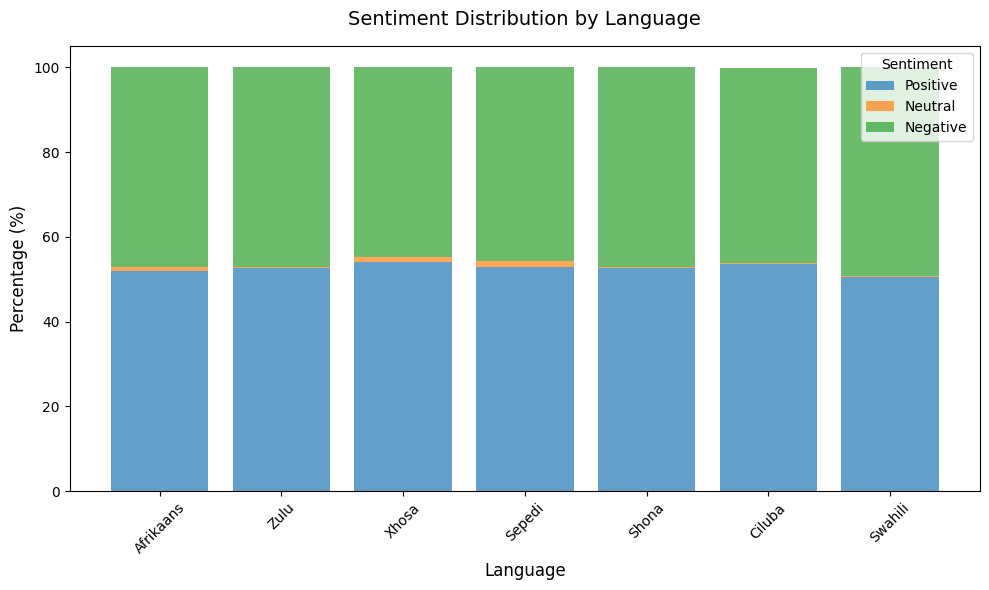

In [26]:
# ==========================================
# 🎨 EDA: VISUALIZATION — SENTIMENT RATIOS PER LANGUAGE
# ==========================================
import matplotlib.pyplot as plt

if "summary_df" not in locals():
    raise ValueError("Run Task D first to generate summary_df.")

plt.figure(figsize=(10, 6))
plt.bar(summary_df["Language"], summary_df["Pos %"], label="Positive", alpha=0.7)
plt.bar(summary_df["Language"], summary_df["Neu %"], bottom=summary_df["Pos %"], label="Neutral", alpha=0.7)
plt.bar(summary_df["Language"], summary_df["Neg %"], 
        bottom=summary_df["Pos %"] + summary_df["Neu %"], label="Negative", alpha=0.7)

plt.title("Sentiment Distribution by Language", fontsize=14, pad=15)
plt.xlabel("Language", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.legend(title="Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()